<div style="font-family: 'consolas'; color: #1A1A1A; font-size: 16px; line-height: 1;"> 
    
### <center>**Ola : Driver Churn Predictions**<center>

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

**Context:**

> Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola. Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

> Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

**Problem Statement:**

Predict whether a driver will be leaving the company or not based on their attributes like :

>	Demographics (city, age, gender etc.)

>	Tenure information (joining date, last working date)

>	Historical data regarding the performance of the driver (quarterly rating, monthly business acquired, grade, income)

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

In [2]:
# loadind and viewing data
df = pd.read_csv("ola_drivers.csv")
df.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [3]:
# removing unwanted column
df.drop('Unnamed: 0',axis=1,inplace=True)

In [4]:
# checking the structure of the dataset/duplicates/number of unique drivers/missing values
print(f'Records              : {df.shape[0]}')
print(f'Features             : {df.shape[1]}')
print(f'Duplicate rows       : {df.duplicated().sum()}')
print(f'Unique driver IDs    : {df['Driver_ID'].nunique()}')
print(f'Total missing values : {df.isnull().sum().sum()}')

Records              : 19104
Features             : 13
Duplicate rows       : 0
Unique driver IDs    : 2381
Total missing values : 17601


In [5]:
# checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MMM-YY                19104 non-null  object 
 1   Driver_ID             19104 non-null  int64  
 2   Age                   19043 non-null  float64
 3   Gender                19052 non-null  float64
 4   City                  19104 non-null  object 
 5   Education_Level       19104 non-null  int64  
 6   Income                19104 non-null  int64  
 7   Dateofjoining         19104 non-null  object 
 8   LastWorkingDate       1616 non-null   object 
 9   Joining Designation   19104 non-null  int64  
 10  Grade                 19104 non-null  int64  
 11  Total Business Value  19104 non-null  int64  
 12  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 1.9+ MB


In [6]:
# percentage of null values in each column
round(df.isnull().sum()/len(df),3)

MMM-YY                  0.000
Driver_ID               0.000
Age                     0.003
Gender                  0.003
City                    0.000
Education_Level         0.000
Income                  0.000
Dateofjoining           0.000
LastWorkingDate         0.915
Joining Designation     0.000
Grade                   0.000
Total Business Value    0.000
Quarterly Rating        0.000
dtype: float64

In [7]:
# datatypes
print(f'columns_numeric : {df.select_dtypes(include='number').shape[1]}')
print(f'columns_object : {df.select_dtypes(include='object').shape[1]}')

columns_numeric : 9
columns_object : 4


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">
    
#### **Observations :**

> 'MMM-YY' to be changed to meaningful name 

> Columns with date values like 'MMM-YY','Dateofjoining','LastWorkingDate' to be converted to date format

> There are 3 columns with missing values - 'Age', 'Gender', 'LastWorkingDate'

> Large missing values in 'LastWorkingDate' are not missing values in actual sense; they are drivers who did not leave the company

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">
    
#### **Handling missing values**

In [8]:
# filling null values in categorical column with mode
mode = df['Gender'].mode()
df['Gender'] = df['Gender'].fillna(mode,axis=0)

In [9]:
# Creating target column: 1 if the driver left (not null), 0 if they stayed (is null)
df['Churn'] = df['LastWorkingDate'].notnull().astype(int)

# removing column 'LastWorkingDate' as it is redundant now 
df.drop('LastWorkingDate',axis=1, inplace=True)

In [10]:
# creating a working copy for scaling & imputing missing values
df_temp = df.copy()

In [11]:
# filling null values in numerical columns with KNN imputation technique
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

# 1. Separate ID and Churn so they don't interfere with KNN distances
df_features = df_temp.drop(['Driver_ID', 'Churn'], axis=1)

# 2. Separate datatypes
df_nums = df_features.select_dtypes(exclude='object')
df_objs = df_features.select_dtypes(include='object')

# 3. Scaling
scaler = MinMaxScaler()
scaled_nums = scaler.fit_transform(df_nums)

# 4. Imputing
imputer = KNNImputer(n_neighbors=5)
imputed_nums = imputer.fit_transform(scaled_nums)

# 5. unscaling back for EDA
unscaled_nums = scaler.inverse_transform(imputed_nums)
df_nums_clean = pd.DataFrame(unscaled_nums, columns=df_nums.columns)

# 6. Reconstructing the entire original dataframe for EDA
df_eda = pd.concat([df_nums_clean,df_objs.reset_index(drop=True)], axis=1)
df_eda = df_eda[df_features.columns] # Restore original column order

# 7. Bring back Driver_ID and Churn at the respective positions
df_eda.insert(0, 'Driver_ID', df_temp['Driver_ID'].values)
df_eda['Churn'] = df_temp['Churn'].values

In [12]:
# checking the shape of the new df
df_eda.shape

(19104, 13)

In [13]:
df_eda.head()

,Driver_ID,MMM-YY,Age,Gender,City,Education_Level,Income,Dateofjoining,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn
0,1,01/01/19,28.0,0.0,C23,2.0,57387.0,24/12/18,1.0,1.0,2381060.0,2.0,0
1,1,02/01/19,28.0,0.0,C23,2.0,57387.0,24/12/18,1.0,1.0,-665480.0,2.0,0
2,1,03/01/19,28.0,0.0,C23,2.0,57387.0,24/12/18,1.0,1.0,0.0,2.0,1
3,2,11/01/20,31.0,0.0,C7,2.0,67016.0,11/06/20,2.0,2.0,0.0,1.0,0
4,2,12/01/20,31.0,0.0,C7,2.0,67016.0,11/06/20,2.0,2.0,0.0,1.0,0


In [14]:
# re-checking null values
df_eda.isnull().sum()

Driver_ID               0
MMM-YY                  0
Age                     0
Gender                  0
City                    0
Education_Level         0
Income                  0
Dateofjoining           0
Joining Designation     0
Grade                   0
Total Business Value    0
Quarterly Rating        0
Churn                   0
dtype: int64

In [15]:
# renaming column and changing its datatype to datetime
df_eda.rename({'MMM-YY':'Reporting_Date'},axis=1,inplace=True)

df_eda['Reporting_Date'] = pd.to_datetime(df_eda['Reporting_Date'], format='%m/%d/%y')
df_eda['Dateofjoining'] = pd.to_datetime(df_eda['Dateofjoining'], format='%d/%m/%y')

In [16]:
# creating a new column to calculate tenure days
tenure_days = (df_eda['Reporting_Date'] - df_eda['Dateofjoining']).dt.days
df_eda['Driver_Tenure_Days'] = np.abs(tenure_days) # because for some rows 'Dateofjoining'< 'Reporting_Date' may be typo!

In [17]:
# shifting columns 
X = df_eda['Dateofjoining']
Y = df_eda['Reporting_Date']
df_eda= df_eda.drop('Dateofjoining',axis=1)
df_eda= df_eda.drop('Reporting_Date',axis=1)
df_eda.insert(1,'Dateofjoining',X)
df_eda.insert(2,'Reporting_Date',Y)

In [18]:
# cleaning 'city' column : C23 to 23
df_eda['City'] = df_eda['City'].astype(str).str.replace(r'\D', '', regex=True).astype(int)

In [19]:
# bringing target variable to the end
df_eda.drop('Churn',axis=1,inplace=True)
df_eda['Churn'] = df['Churn'].values

In [20]:
df_eda.head()

,Driver_ID,Dateofjoining,Reporting_Date,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Driver_Tenure_Days,Churn
0,1,2018-12-24,2019-01-01,28.0,0.0,23,2.0,57387.0,1.0,1.0,2381060.0,2.0,8,0
1,1,2018-12-24,2019-02-01,28.0,0.0,23,2.0,57387.0,1.0,1.0,-665480.0,2.0,39,0
2,1,2018-12-24,2019-03-01,28.0,0.0,23,2.0,57387.0,1.0,1.0,0.0,2.0,67,1
3,2,2020-06-11,2020-11-01,31.0,0.0,7,2.0,67016.0,2.0,2.0,0.0,1.0,143,0
4,2,2020-06-11,2020-12-01,31.0,0.0,7,2.0,67016.0,2.0,2.0,0.0,1.0,173,0


In [21]:
#converting the columns designated as float after KNN imputation to int datatype
int_columns = ['Driver_ID','Age', 'Gender','Education_Level','Income','Joining Designation','Grade','Total Business Value','Churn','Quarterly Rating']

# 2. Round the values (KNN might impute an average like 28.4 for Age)
df_eda[int_columns] = df_eda[int_columns].round()

# 3. Cast them back to integer data types
df_eda[int_columns] = df_eda[int_columns].astype(int)

In [22]:
# final check
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Driver_ID             19104 non-null  int64         
 1   Dateofjoining         19104 non-null  datetime64[ns]
 2   Reporting_Date        19104 non-null  datetime64[ns]
 3   Age                   19104 non-null  int64         
 4   Gender                19104 non-null  int64         
 5   City                  19104 non-null  int64         
 6   Education_Level       19104 non-null  int64         
 7   Income                19104 non-null  int64         
 8   Joining Designation   19104 non-null  int64         
 9   Grade                 19104 non-null  int64         
 10  Total Business Value  19104 non-null  int64         
 11  Quarterly Rating      19104 non-null  int64         
 12  Driver_Tenure_Days    19104 non-null  int64         
 13  Churn           

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">
    
> Thus there are 12 features and a target column.
>
> No of numerical features - 10
>
> No of datetime features - 2
>
> Target Variable - Binary (0/1)

In [23]:
# statistical summary
df_eda.describe(include=['number'])

,Driver_ID,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Driver_Tenure_Days,Churn
count,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000,19104.000000,19104.000000
mean,1415.591133,34.656826,0.418708,15.593959,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899,608.134108,0.084590
std,810.705321,6.258501,0.493360,8.470071,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832,651.200975,0.278277
min,1.000000,21.000000,0.000000,1.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000,0.000000,0.000000
25%,710.000000,30.000000,0.000000,8.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000,115.000000,0.000000
50%,1417.000000,34.000000,0.000000,16.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000,319.000000,0.000000
75%,2137.000000,39.000000,1.000000,23.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000,1002.250000,0.000000
max,2788.000000,58.000000,1.000000,29.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000,2888.000000,1.000000


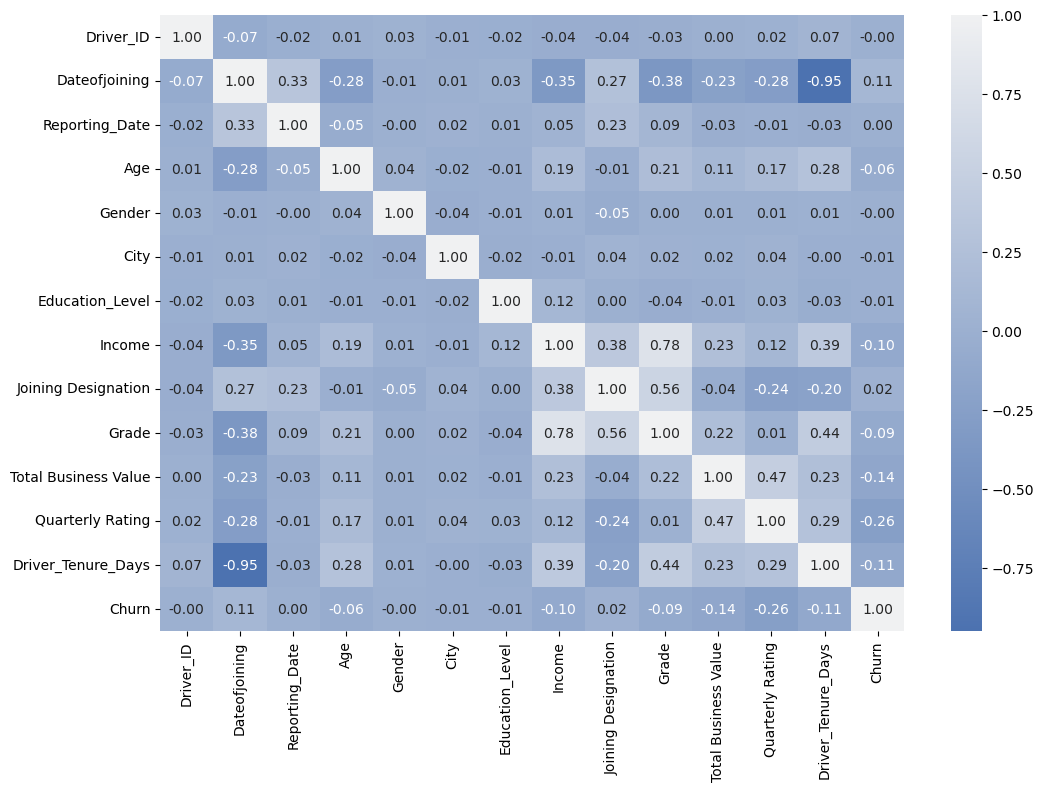

In [24]:
# checking collinarity
crimson_cmap = sns.light_palette("#4C72B0", as_cmap=True, reverse=True)
plt.figure(figsize=(12,8))
sns.heatmap(df_eda.corr(),annot=True,cmap=crimson_cmap, fmt=".2f")
plt.show()

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">
    
#### **Observations :**

> 'DateofJoining' vs 'Driver_Tenure_Days -> -0.95

> 'Grade' vs 'Income' -> 0.78

In [25]:
# removing features with high correlation
df_eda.drop(columns = ['Dateofjoining','Grade'],axis=1,inplace=True)

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1;">
    
#### **Feature Engineering**

In [26]:
# checking if quarterly rating increased for a driver in his tenure: 1-yes 0-no
df_eda['QR_inc_dec'] = df_eda.groupby('Driver_ID')['Quarterly Rating'].transform(
    lambda x: 1 if x.min() < x.max() else 0)

# checking if income increased for a driver in his tenure: 1-yes 0-no
df_eda['income_inc_dec'] = df_eda.groupby('Driver_ID')['Income'].transform(
    lambda x: 1 if x.min() < x.max() else 0)

# checking if total business value is positive or negative for a driver in his tenure: 1-yes 0-no
df_eda['Total Business Value_pos_neg'] = df_eda.groupby('Driver_ID')['Total Business Value'].transform(
    lambda x: 1 if x.sum() >0 else 0)

In [27]:
df_eda.head()

,Driver_ID,Reporting_Date,Age,Gender,City,Education_Level,Income,Joining Designation,Total Business Value,Quarterly Rating,Driver_Tenure_Days,Churn,QR_inc_dec,income_inc_dec,Total Business Value_pos_neg
0,1,2019-01-01,28,0,23,2,57387,1,2381060,2,8,0,0,0,1
1,1,2019-02-01,28,0,23,2,57387,1,-665480,2,39,0,0,0,1
2,1,2019-03-01,28,0,23,2,57387,1,0,2,67,1,0,0,1
3,2,2020-11-01,31,0,7,2,67016,2,0,1,143,0,0,0,0
4,2,2020-12-01,31,0,7,2,67016,2,0,1,173,0,0,0,0


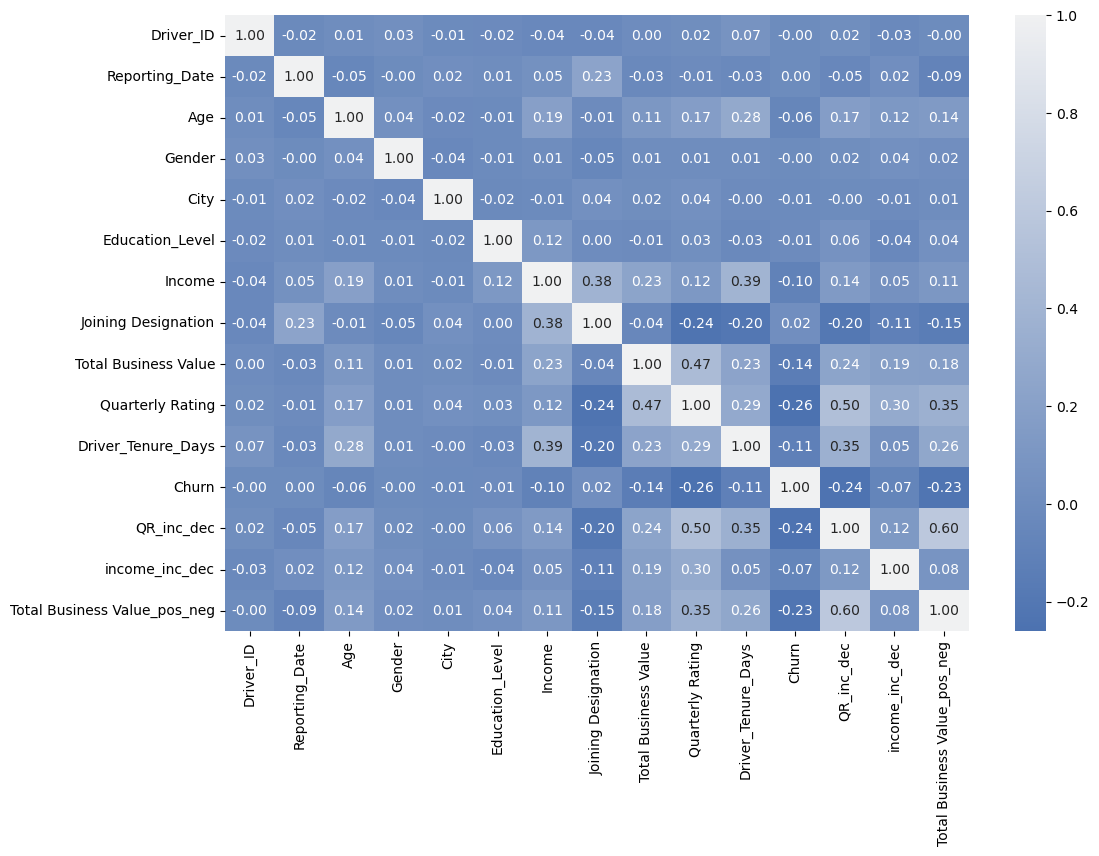

In [28]:
# checking correlation with newly created features
crimson_cmap = sns.light_palette("#4C72B0", as_cmap=True, reverse=True)
plt.figure(figsize=(12,8))
sns.heatmap(df_eda.corr(),annot=True,cmap=crimson_cmap, fmt=".2f")
plt.show()

In [29]:
# aggregating the data at the driver level
driver_level = df_eda.groupby(['Driver_ID']).agg({
                                'Age': 'max',
                                'Gender':'last',
                                'Income':'last',
                                'Joining Designation':'last',
                                'Quarterly Rating':'max',
                                'City':'last',
                                'Total Business Value':'sum',
                                'Driver_Tenure_Days':'max',
                                'Churn':'max',
                                'income_inc_dec':'max',
                                'QR_inc_dec':'max',
                                'Total Business Value_pos_neg':'max'}).reset_index()
driver_level.head(5)

,Driver_ID,Age,Gender,Income,Joining Designation,Quarterly Rating,City,Total Business Value,Driver_Tenure_Days,Churn,income_inc_dec,QR_inc_dec,Total Business Value_pos_neg
0,1,28,0,57387,1,2,23,1715580,67,1,0,0,1
1,2,31,0,67016,2,1,7,0,173,0,0,0,0
2,4,43,0,65603,2,1,13,350000,264,1,0,0,1
3,5,29,0,46368,1,1,9,120360,243,1,0,0,1
4,6,31,1,78728,3,2,11,1265000,123,0,0,1,1


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

#### **Univariate Analysis**

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> #### **Age**

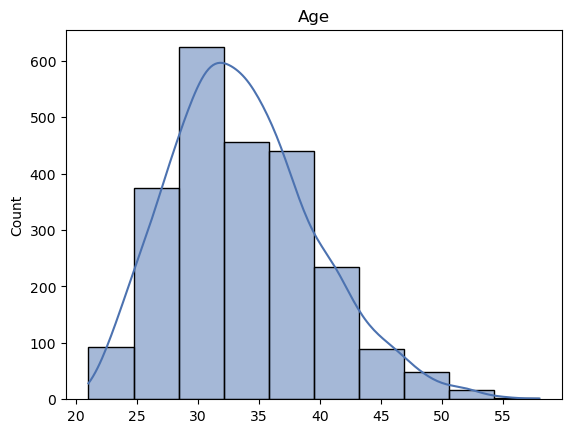

In [30]:
sns.histplot(driver_level['Age'],bins=10,color='#4C72B0',kde=True)
plt.xlabel('')
plt.title('Age')
plt.show()

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

Most of the drivers are in the age group - 25-40 with some elder drivers too with age above 55.

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> #### **Gender**

In [31]:
round(driver_level['Gender'].value_counts(normalize=True),2)

Gender
0    0.59
1    0.41
Name: proportion, dtype: float64

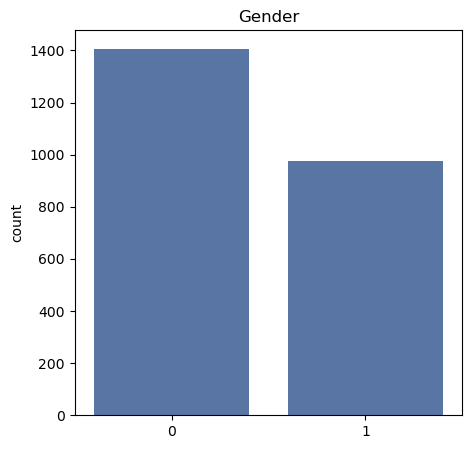

In [32]:
plt.figure(figsize=(5,5))
sns.barplot(x=driver_level['Gender'].value_counts().index,y=driver_level['Gender'].value_counts().values,color='#4C72B0')
plt.xlabel("")
plt.ylabel('count')
plt.title('Gender')
plt.show()

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

Around 60% of the drivers are male

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> #### **City**

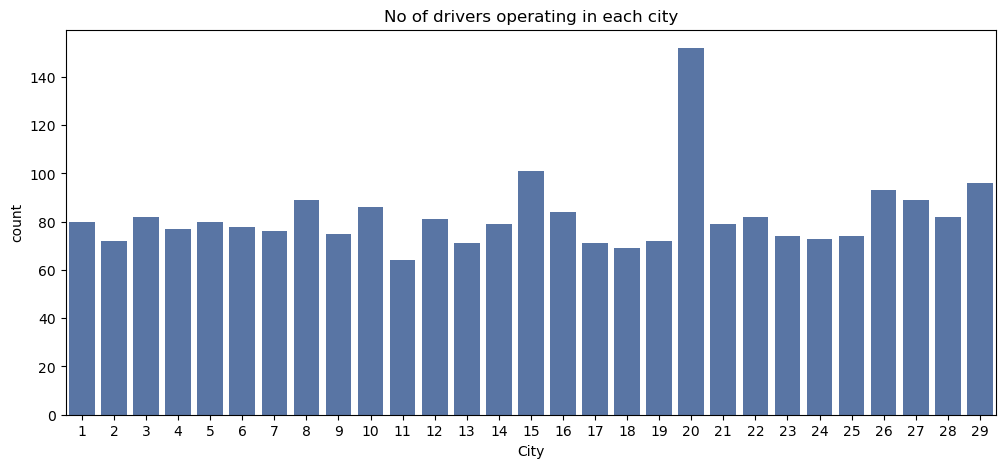

In [33]:
plt.figure(figsize=(12,5))
sns.barplot(x=driver_level['City'].value_counts().index,y=driver_level['City'].value_counts().values,color='#4C72B0')
plt.ylabel('count')
plt.title('No of drivers operating in each city')
plt.show()

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

city -20 has maximum drivers (approx 150)

Rest of the cities has < 100 drivers

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> #### **Driver Tenure Days**

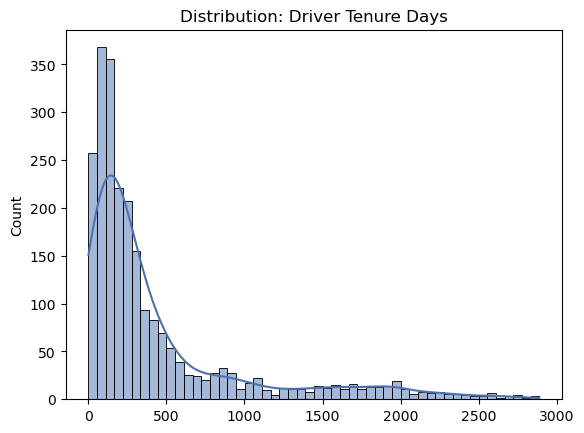

In [34]:
sns.histplot(driver_level['Driver_Tenure_Days'],color='#4C72B0',kde=True)
plt.xlabel("")
plt.title('Distribution: Driver Tenure Days')
plt.show()

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

Most of the drivers joined the platform 1 year back.

Long tail in the right suggests there are drivers who joined the platform many years back.

In [35]:
churn_mean_tenure = driver_level.groupby('Churn')['Driver_Tenure_Days'].mean()
churn_mean_tenure

Churn
0    591.464052
1    370.781559
Name: Driver_Tenure_Days, dtype: float64

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> #### **Average Tenure**

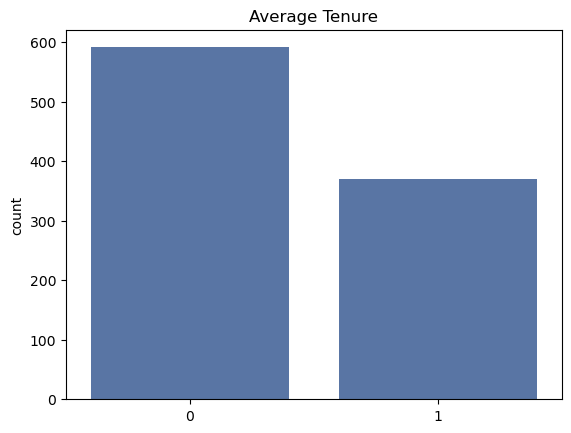

In [36]:
sns.barplot(x=churn_mean_tenure.index,y= churn_mean_tenure.values,color='#4C72B0')
plt.xlabel("")
plt.ylabel('count')
plt.title('Average Tenure')
plt.show()

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

Most of the drivers who left the company did not operate for more than 1 year suggesting a critical relationship with the target variable

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> #### **Quarterly Rating**

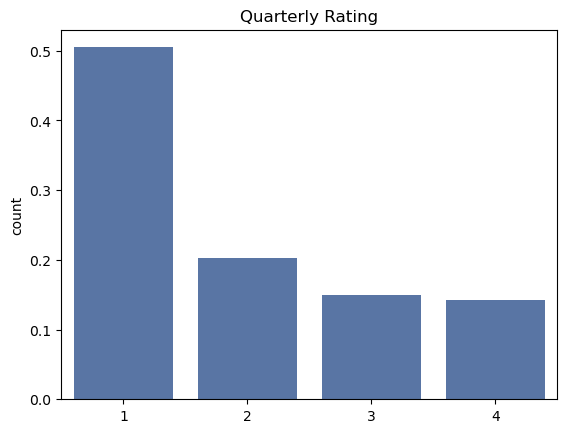

In [37]:
sns.barplot(x=driver_level['Quarterly Rating'].value_counts().index,y=driver_level['Quarterly Rating'].value_counts(normalize=True).values,color='#4C72B0')
plt.xlabel("")
plt.ylabel('count')
plt.title('Quarterly Rating')
plt.show()

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

Around 50% of the drivers have quarterly rating of 1 

In [38]:
driver_level.groupby('Churn')['Quarterly Rating'].value_counts(normalize=True)

Churn  Quarterly Rating
0      1                   0.325490
       4                   0.305882
       3                   0.203922
       2                   0.164706
1      1                   0.589728
       2                   0.221535
       3                   0.123144
       4                   0.065594
Name: proportion, dtype: float64

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

Around 59% of the drivers who left the company got quarterly rating of 1 and 22% of the drivers got quarterly rating of 2

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> #### **Income**

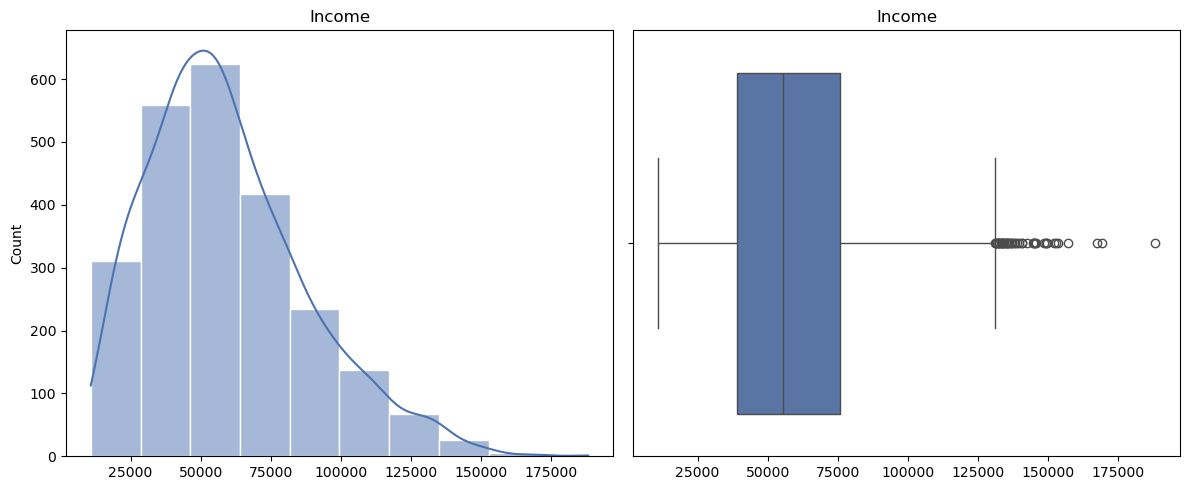

In [39]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(driver_level['Income'],bins=10,color = '#4C72B0',kde=True,edgecolor="white")
plt.xlabel('')
plt.title('Income')

plt.subplot(1,2,2)
sns.boxplot(x=driver_level['Income'],color='#4C72B0')
plt.xlabel('')
plt.title('Income')

plt.tight_layout()
plt.show()

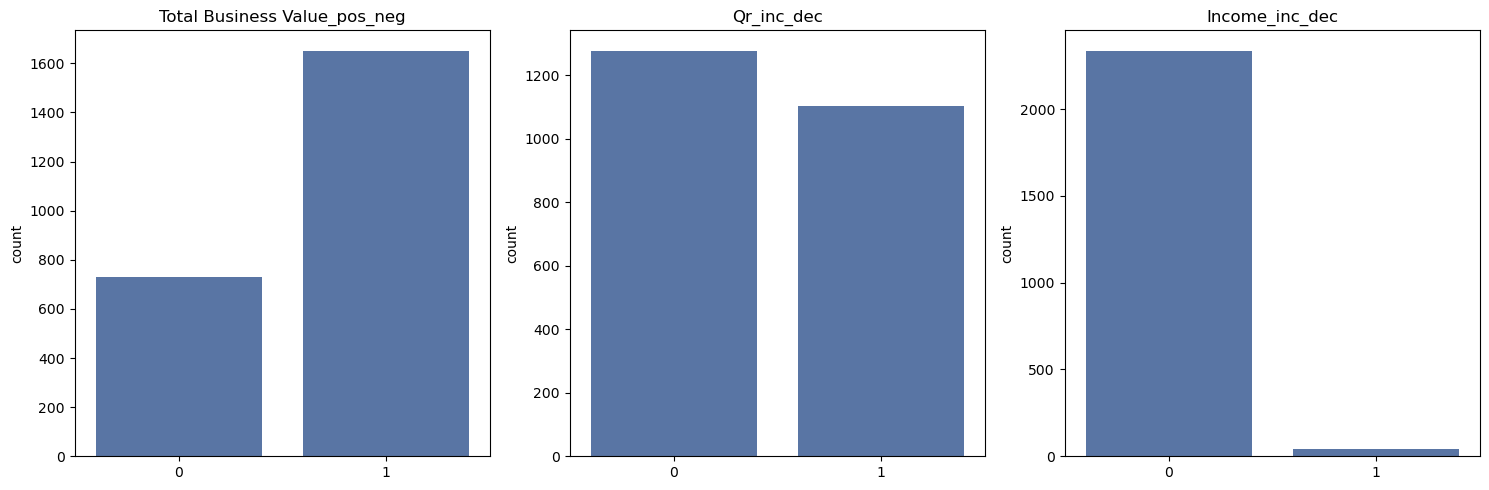

In [40]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.countplot(x=driver_level['Total Business Value_pos_neg'],color='#4C72B0')
plt.xlabel('')
plt.title('Total Business Value_pos_neg')

plt.subplot(1,3,2)
sns.countplot(x=driver_level['QR_inc_dec'],color='#4C72B0')
plt.xlabel('')
plt.title('Qr_inc_dec')

plt.subplot(1,3,3)
sns.countplot(x=driver_level['income_inc_dec'],color='#4C72B0')
plt.xlabel('')
plt.title('Income_inc_dec')

plt.tight_layout()
plt.show()

In [41]:
driver_level['Total Business Value_pos_neg'].value_counts(normalize = True)

Total Business Value_pos_neg
1    0.693826
0    0.306174
Name: proportion, dtype: float64

In [42]:
driver_level['QR_inc_dec'].value_counts(normalize = True)

QR_inc_dec
0    0.536329
1    0.463671
Name: proportion, dtype: float64

In [43]:
driver_level['income_inc_dec'].value_counts(normalize = True)

income_inc_dec
0    0.98152
1    0.01848
Name: proportion, dtype: float64

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> Around 70% of the drivers has total busines value in the positive side(profitable cohort) and 30% has business value in the negative side(unprofitable cohort).
>
> For around 53% of the drivers, there were no increase in the quarterly rating and for 43%, quarterly rating increased in their tenure.
>
> For around 98% of the drivers, there were no increase in income and for 2% income increased in their tenure.

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

#### **Bivariate Analysis**

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

> **Age vs Churn**

In [44]:
age_churn_prob = driver_level.groupby('Age').agg(
                                total_count=('Churn', 'count'),
                                Churn_count=('Churn', 'sum'),
                                Churn_probability=('Churn', 'mean')
                            ).reset_index().sort_values(by=['total_count','Churn_count'],ascending=False).reset_index(drop=True)
age_churn_prob

,Age,total_count,Churn_count,Churn_probability
0,31,167,123,0.736527
1,32,167,120,0.718563
2,34,166,115,0.692771
3,30,156,99,0.634615
4,33,152,109,0.717105
5,35,138,83,0.601449
6,36,137,84,0.613139
7,29,134,87,0.649254
8,37,123,69,0.560976
9,28,120,89,0.741667


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> Age group 30-34 has the highest head count and churn probability of 65%-73%, reveals a severe, highly critical operational bottleneck for Ola's supply network

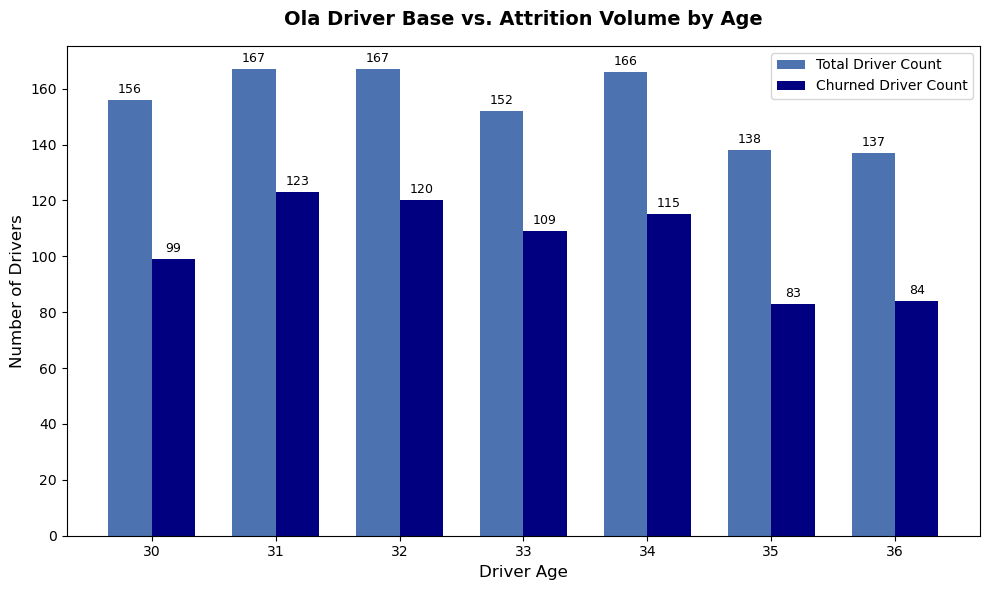

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Recreate your dataset from the image
data = {
    'Age': [31, 32, 34, 30, 33, 35, 36],
    'total_count': [167, 167, 166, 156, 152, 138, 137],
    'Churn_count': [123, 120, 115, 99, 109, 83, 84],
    'Churn_probability': [0.736527, 0.718563, 0.692771, 0.634615, 0.717105, 0.601449, 0.613139]
}
df = pd.DataFrame(data)

# Sort by age so the chart reads logically from left to right
df = df.sort_values('Age').reset_index(drop=True)

# 2. Set up the plotting positions
x = np.arange(len(df['Age'])) 
width = 0.35  # Width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot the clustered bars
rects1 = ax.bar(x - width/2, df['total_count'], width, label='Total Driver Count', color='#4C72B0')
rects2 = ax.bar(x + width/2, df['Churn_count'], width, label='Churned Driver Count', color='#000080')

# 4. Add formatting and text labels
ax.set_ylabel('Number of Drivers', fontsize=12)
ax.set_xlabel('Driver Age', fontsize=12)
ax.set_title('Ola Driver Base vs. Attrition Volume by Age', fontsize=14, pad=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Age'])
ax.legend()


# Optional: Add text values right on top of the bars
ax.bar_label(rects1, padding=3, fontsize=9)
ax.bar_label(rects2, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

> **Churn vs Quarterly Rating**

In [46]:
QR_churn_prob = driver_level.groupby('Quarterly Rating').agg(
                                                total_count=('Churn', 'count'),
                                                Churn_count=('Churn', 'sum'),
                                                Churn_probability=('Churn', 'mean')
                            ).reset_index().sort_values(by=['total_count','Churn_count'],ascending=False).reset_index(drop=True)

In [47]:
QR_churn_prob

,Quarterly Rating,total_count,Churn_count,Churn_probability
0,1,1202,953,0.792845
1,2,484,358,0.739669
2,3,355,199,0.560563
3,4,340,106,0.311765


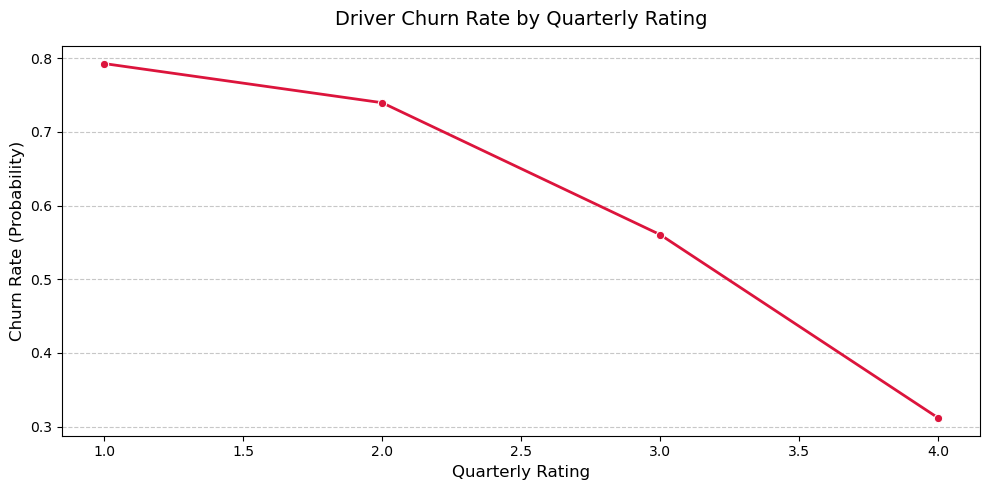

In [48]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=QR_churn_prob, x='Quarterly Rating', y='Churn_probability', marker='o', color='crimson', linewidth=2)

plt.title('Driver Churn Rate by Quarterly Rating', fontsize=14, pad=15)
plt.xlabel('Quarterly Rating', fontsize=12)
plt.ylabel('Churn Rate (Probability)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

Most of the drivers who left the company were given quarterly rating as 1 in their tenure with a churn probability of 79% and drivers who got quarterly rating of 4 are less likely to leave the company with a probability of 31%

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

> **Churn vs Gender**

In [49]:
QR_gender_prob = driver_level.groupby('Gender').agg(
                                                total_count=('Churn', 'count'),
                                                Churn_count=('Churn', 'sum'),
                                                Churn_probability=('Churn', 'mean')
                            ).reset_index().sort_values(by=['total_count','Churn_count'],ascending=False).reset_index(drop=True)
QR_gender_prob

,Gender,total_count,Churn_count,Churn_probability
0,0,1407,949,0.674485
1,1,974,667,0.684805


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

Churn probability is similar in both gender cases. This minor variation suggests that gender may not be a strong, standalone differentiating factor for churn.

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

> **Churn Probability vs Performance/Financial Metrics**

In [50]:
# performace
performance = driver_level.groupby(['income_inc_dec','QR_inc_dec','Total Business Value_pos_neg']).agg(
                                                total_count=('Churn', 'count'),
                                                Churn_count=('Churn', 'sum'),
                                                Churn_probability=('Churn', 'mean')
                            ).reset_index().sort_values(by=['income_inc_dec','QR_inc_dec','Total Business Value_pos_neg'],ascending=True).reset_index(drop=True)
performance

,income_inc_dec,QR_inc_dec,Total Business Value_pos_neg,total_count,Churn_count,Churn_probability
0,0,0,0,728,562,0.771978
1,0,0,1,548,424,0.773723
2,0,1,0,1,0,0.000000
3,0,1,1,1060,627,0.591509
4,1,0,1,1,0,0.000000
5,1,1,1,43,3,0.069767


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

>  Drivers who did not get any increase in income and quarterly rating (0) have the highest churn rates, regardless of their business value(77%).
>
> When income is stagnant, an increasing quarterly rating (1) drops the churn probability significantly from ~77% down to 59.15% (for positive business value).
>
> When both income and quarterly ratings are 1, the churn risk plummets dramatically to a very safe 6.98%.

In [51]:
# checking class imbalance
round(df_eda['Churn'].value_counts(normalize=True),2)


Churn
0    0.92
1    0.08
Name: proportion, dtype: float64

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

> There is a clear class imbalance with 92% non-churn dominating 8% churn.
>
> **Impact on Bagging Models (e.g., Random Forest)**
>
> > Bagging relies on independent bootstrap sampling (sampling with replacement) to train multiple base estimators.
> >
> > Majority Dominance: Bootstrap samples drawn from an imbalanced dataset will naturally contain very few minority class examples.
> >
> > Poor Splitting: Individual trees split nodes to maximize overall purity (e.g., Gini impurity). They will favor predicting the majority class to minimize error.
> >
> > Underestimated Voting: The final majority vote will be heavily skewed toward the majority class, resulting in high precision but abysmal recall for the minority class.
> >
> **Impact on Boosting Models (e.g., XGBoost, LightGBM, Gradient Boosting)**
>
> > Boosting builds trees sequentially, where each new tree focuses on correcting the errors (residuals) of the previous ones.
> >
> > Better Adaptability: Because boosting forces subsequent trees to focus on hard-to-classify points (which often includes the rare minority class), it naturally handles mild imbalance better than bagging.
> >
> > Vulnerability to Noise: In cases of extreme imbalance, boosting models can overfit. They may obsess over rare minority outliers or noise, treating them as structural patterns.
> >
> > Loss Function Bias: Default loss functions minimize global error. The model may still decide that misclassifying the minority class yields a lower overall loss than shifting decision boundaries.

In [52]:
df_eda.head()

,Driver_ID,Reporting_Date,Age,Gender,City,Education_Level,Income,Joining Designation,Total Business Value,Quarterly Rating,Driver_Tenure_Days,Churn,QR_inc_dec,income_inc_dec,Total Business Value_pos_neg
0,1,2019-01-01,28,0,23,2,57387,1,2381060,2,8,0,0,0,1
1,1,2019-02-01,28,0,23,2,57387,1,-665480,2,39,0,0,0,1
2,1,2019-03-01,28,0,23,2,57387,1,0,2,67,1,0,0,1
3,2,2020-11-01,31,0,7,2,67016,2,0,1,143,0,0,0,0
4,2,2020-12-01,31,0,7,2,67016,2,0,1,173,0,0,0,0


In [53]:
# dropping date column
df_eda.drop('Reporting_Date',axis=1, inplace=True)

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

**Preparing data for modelling**


In [54]:
# seperating target and features
X = df_eda.drop(columns=['Driver_ID', 'Churn','QR_inc_dec','income_inc_dec','Total Business Value_pos_neg'])
y = df_eda['Churn']

In [55]:
# splitting the data as training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [56]:
print(f'Training Data : {X_train.shape}')
print(f'Testing Data : {X_test.shape}')

Training Data : (15283, 9)
Testing Data : (3821, 9)


In [57]:
# checking proportion of churn/non-churn in training and testing targt data
y_train.value_counts(normalize=True)

Churn
0    0.915396
1    0.084604
Name: proportion, dtype: float64

In [58]:
y_test.value_counts(normalize=True)

Churn
0    0.915467
1    0.084533
Name: proportion, dtype: float64

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

#### **Building the Model**

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

> ##### **RandomForest Classifier**

In [59]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report,roc_auc_score

# Initialize the Random Forest with balanced weights for 92:8 split
baseline_tree = RandomForestClassifier(     
    class_weight='balanced_subsample',
    random_state=42
)

# Fit the model
baseline_tree.fit(X_train, y_train)

# checking training performance
y_train_pred = baseline_tree.predict(X_train)
y_train_prob = baseline_tree.predict_proba(X_train)[:, 1]

print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))

train_roc_auc = roc_auc_score(y_train, y_train_prob)
print(f"Training ROC-AUC Score: {train_roc_auc:.4f}")

=== Training Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13990
           1       1.00      1.00      1.00      1293

    accuracy                           1.00     15283
   macro avg       1.00      1.00      1.00     15283
weighted avg       1.00      1.00      1.00     15283

Training ROC-AUC Score: 1.0000


In [60]:
y_test_pred = baseline_tree.predict(X_test)
y_test_prob = baseline_tree.predict_proba(X_test)[:, 1]

# 2. Print your new test results
print("=== New Test Classification Report ===")
print(classification_report(y_test, y_test_pred))
print(f"New Test ROC-AUC Score: {roc_auc_score(y_test, y_test_prob):.4f}")

=== New Test Classification Report ===
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3498
           1       0.18      0.06      0.08       323

    accuracy                           0.90      3821
   macro avg       0.55      0.52      0.52      3821
weighted avg       0.86      0.90      0.87      3821

New Test ROC-AUC Score: 0.8226


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> This is the classic case of model overfitting ! as it can be observed from the very low scores in case of churn.

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">
    
RandomizedSearchCV is an automated optimization tool provided by Scikit-Learn. It finds the best settings (hyperparameters) for our machine learning model without wasting massive amounts of time.

In [62]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 300),     # random integer between 50–300
    'max_depth': randint(2, 10),          # random integer between 2–10
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': [2,5,10,15],
    'ccp_alpha': [0.1,0.01,0.5]
}

# Randomized search setup
rand_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=20,          # number of random combinations to try
    scoring='roc_auc',
    cv=3
)

# Fit
rand_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'ccp_alpha': [0.1, 0.01, 0.5],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000025A4EB5D5B0>,
                                        'max_features': [2, 5, 10, 15],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000025A4E4919D0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000025A4E491BF0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000025A4D17F950>},
                   scoring='roc_auc')

In [63]:
print("Best params:", rand_search.best_params_)
print("Best score: ", rand_search.best_score_)

Best params: {'ccp_alpha': 0.01, 'max_depth': 2, 'max_features': 5, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 138}
Best score:  0.8258940593875498


In [64]:
# re-training the model with best parameters selected from RandomizedSearchCV
baseline_tree = RandomForestClassifier(
    n_estimators = 138,
    max_depth=2,              
    max_features = 5,
    min_samples_leaf=1,      
    min_samples_split=6,
    class_weight='balanced_subsample',
    random_state=42,
    ccp_alpha=0.01
)

# 3. Fit the model
baseline_tree.fit(X_train, y_train)

# checking training performance
y_train_pred = baseline_tree.predict(X_train)
y_train_prob = baseline_tree.predict_proba(X_train)[:, 1]

print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))

train_roc_auc = roc_auc_score(y_train, y_train_prob)
print(f"Training ROC-AUC Score: {train_roc_auc:.4f}")

=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.71      0.82     13990
           1       0.22      0.88      0.35      1293

    accuracy                           0.72     15283
   macro avg       0.60      0.80      0.59     15283
weighted avg       0.92      0.72      0.78     15283

Training ROC-AUC Score: 0.8636


In [65]:
y_test_pred = baseline_tree.predict(X_test)
y_test_prob = baseline_tree.predict_proba(X_test)[:, 1]

# 2. Print your new test results
print("=== New Test Classification Report ===")
print(classification_report(y_test, y_test_pred))
print(f"New Test ROC-AUC Score: {roc_auc_score(y_test, y_test_prob):.4f}")

=== New Test Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.70      0.82      3498
           1       0.21      0.87      0.34       323

    accuracy                           0.71      3821
   macro avg       0.60      0.78      0.58      3821
weighted avg       0.92      0.71      0.78      3821

New Test ROC-AUC Score: 0.8658


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

#### **Comments :**

> Recall --> 0.87: Out of 323 drivers who actually churned, the model successfully flagged 87% of them (roughly 265 drivers).
>
> A Strong ROC-AUC (0.8658): An area under the curve of 0.8607 means the model has a very high mathematical ability to distinguish a churning driver from an active one across various decision thresholds.
>
> The Low Precision Trade-Off (0.21):  This means when the model flags a driver as a churn risk, they actually leave 21% of the time, while the other 77% are false alarms.
>
In driver retention, high recall is far more valuable than high precision. 

The Cost of a False Negative (Missing a Churner): If a high-performing driver leaves the platform because the model missed them, company lose thousands of dollars in ride revenue and have to spend heavy marketing budget to recruit a replacement driver.

<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 16px; line-height: 1.5;">

> **XGBoost Classifier :**

In [66]:
from sklearn.model_selection import StratifiedKFold

xgb_base = XGBClassifier(
    scale_pos_weight=10.83,       # Balance your 92:8 class ratio
    learning_rate=0.05,           # Fixed learning rate for stable sequential steps
    random_state=42,
    eval_metric='logloss'         # Core loss evaluation metric
)

param_distributions = {
    'n_estimators':[50, 100, 150, 200, 300], # Number of sequential trees
    'max_depth':[3, 4, 5, 6, 7, 8],                 # Keep shallow to prevent training memorization
    'min_child_weight':[1, 3, 5, 7, 10],          # Minimum cluster size needed for a new split
    'subsample': [0.7, 0.8, 0.9],              # Row fraction sampled per tree
    'colsample_bytree': [0.7, 0.8, 0.9],       # Feature fraction sampled per tree
    'gamma': [0, 0.1, 0.2, 0.3]                # Minimum loss reduction needed to split a leaf
}

# 3. Use StratifiedKFold to enforce your 92:8 class distribution across all 5 folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Setup the RandomizedSearchCV framework
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=15,                    # Number of random parameter combinations to try
    cv=cv_strategy,               # Injects stratified cross-validation
    scoring='roc_auc',            # Optimizes for structural area under the curve
    random_state=42,
    n_jobs=-1,                    # Multi-core processing for maximum execution speed
    verbose=2                     # Live logging printout to verify progress
)

# 5. Execute the tuning search ONLY on your training set
print("Starting XGBoost hyperparameter tuning search...")
random_search_xgb.fit(X_train, y_train)

# 6. Extract the champion parameters
print(f"\nOptimal Parameters Discovered: {random_search_xgb.best_params_}")

# 7. Evaluate the winning model on your test data
best_xgb_model = random_search_xgb.best_estimator_
y_test_pred = best_xgb_model.predict(X_test)
y_test_prob = best_xgb_model.predict_proba(X_test)[:, 1]

Starting XGBoost hyperparameter tuning search...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Optimal Parameters Discovered: {'subsample': 0.7, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 3, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [70]:
# retraining the model with the selected parameters from StratifiedKFold
xgb_base = XGBClassifier(
                        n_estimators = 150,
                        min_child_weight = 3,
                        subsample = 0.7,
                        colsample_bytree = 0.8,
                        max_depth = 3,
                        scale_pos_weight=10.83,       
                        learning_rate=0.05,           
                        random_state=42,
                        eval_metric='logloss',
                        gamma = 0.3
                        )
#fitting the model
xgb_base.fit(X_train, y_train)

# checking training performance
y_train_pred = xgb_base.predict(X_train)
y_train_prob = xgb_base.predict_proba(X_train)[:, 1]

print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))

train_roc_auc = roc_auc_score(y_train, y_train_prob)
print(f"Training ROC-AUC Score: {train_roc_auc:.4f}")

=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     13990
           1       0.28      0.85      0.42      1293

    accuracy                           0.80     15283
   macro avg       0.63      0.83      0.65     15283
weighted avg       0.92      0.80      0.84     15283

Training ROC-AUC Score: 0.8930


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

> Training roc-auc score improved to 0.89 from 0.86 


In [71]:
y_test_pred = xgb_base.predict(X_test)
y_test_prob = xgb_base.predict_proba(X_test)[:, 1]

# 2. Print your new test results
print("=== New Test Classification Report ===")
print(classification_report(y_test, y_test_pred))
print(f"New Test ROC-AUC Score: {roc_auc_score(y_test, y_test_prob):.4f}")

=== New Test Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      3498
           1       0.27      0.82      0.41       323

    accuracy                           0.80      3821
   macro avg       0.63      0.81      0.64      3821
weighted avg       0.92      0.80      0.84      3821

New Test ROC-AUC Score: 0.8762


<div style="font-family: 'Consolas'; color:  #1A1A1A; font-size: 14px; line-height: 1.5;">

#### **Comments :**

> test roc-auc score improved to 0.87 from 0.86
> 
> f1-score imporoved to 0.41(churn) from 0.36 compared to RandomForest
>
> Recall is 0.82  which means the model is effectively detecting true positives(churn) in 82% of the times
>
> No noticeable change in precision

<div style="font-family: 'Roboto mono'; color: #000080; font-size: 16px; line-height: 1;"> 
    
### <center>**Insights & Recommendations**<center>

<div style="font-family: 'Roboto mono'; color: #000080; font-size: 18px; line-height: 1.5;">

> Male drivers constitute of 59% and Female drivers constitute 41%.
>
> City C20 has predominantly more drivers (~7%) than any other other cities (total 29 operating cities).
>
> The mean tenure days for churned drivers is 370 days whereas for non churned drivers its 591 days, suggesting that once a driver survives the 1-year friction point, their loyalty and habits stabilize, making them much less likely to leave the Ola platform.
>
> Around 50% of the drivers has quarterly rarting of 1 and around 79% of the total drivers who left the company never saw an improvement in their rating beyond 1. This proves that a lack of upward mobility or failure to recover from a poor start is the single biggest psychological or financial driver of attrition.
>
> Around 98% of the drivers did not saw an increment in their income suggesting a systemic degradation in driver incentives and motivation to continue with the service.
>
> Age Group 30–34 has the highest headcount yet suffers an extreme 65%–73% churn rate. This specific age group represents prime-working-age, career-driven individuals who likely view driving as a primary source of income rather than a part-time gig. These age group often face major life milestones (supporting families, paying off vehicle loans, or managing households). They cannot afford to tolerate the stagnant income or ratings.
>
> Drivers who did not get any increase in income and quarterly rating have the highest churn rates, regardless of their business value(77%).   Ola's internal rating and allocation algorithms should focus entirely on treating High-Business-Value / Low-Rating drivers.